# Standard Prefix-Tuning Baseline — Training and Evaluation

This notebook trains and evaluates the **Standard Prefix-Tuning baseline** used in the thesis.

The backbone is `meta-llama/Llama-3.1-8B-Instruct`, kept frozen while a learnable continuous prefix is optimized using the Hugging Face PEFT implementation of Prefix-Tuning.

Training uses the **Balanced CEFR Steering Subset**, containing 5,568 examples with equal representation across the six CEFR levels (A1–C2). A stratified 90/10 train-validation split is applied with `random_state=42`.

The Prefix-Tuning configuration uses 30 virtual tokens with prefix projection enabled. The model is trained with the standard causal language-modeling objective while prompt and padding tokens are excluded from the loss.

The notebook includes:

- Standard Prefix-Tuning configuration and training;
- validation-loss and perplexity tracking;
- publication of the trained adapter to Hugging Face;
- generation on the final In-Domain Evaluation Prompt Matrix;
- evaluation using the primary Joint-Loss CEFR evaluator;
- CEFR-control and linguistic diagnostic metrics.

The trained Prefix-Tuning adapter is evaluated on the same 702-condition in-domain benchmark used for the other control methods in the thesis.

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & DEPENDENCIES
# =========================================================
!pip install -q transformers peft torch datasets huggingface_hub accelerate scikit-learn hf_transfer tqdm nvidia-ml-py "torchao>=0.16.0"
!python -m spacy download en_core_web_sm

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import json
import math
import time
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    get_cosine_schedule_with_warmup
)
from peft import PrefixTuningConfig, get_peft_model, TaskType
from huggingface_hub import login, HfApi
from google.colab import drive, userdata
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 106.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 118.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Configuration Paths - Updated for Standard Prefix-Tuning
BALANCED_CSV_PATH = "/content/drive/MyDrive/Your_Path/balanced_cefr_steering_subset.csv"
HF_REPO_ID = "MohammadKhosravi/llama3.1-8b-standard-prefix-tuning-6k"
DRIVE_LOG_DIR = "/content/drive/MyDrive/Your_Path/standard_prefix_tuning_training_logs"
LOCAL_OUTPUT_DIR = "./standard_prefix_tuning_hf_export"

os.makedirs(DRIVE_LOG_DIR, exist_ok=True)
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using execution device: {device}")

Mounted at /content/drive
Using execution device: cuda


In [ ]:
# ==========================================
# 1. INGEST BALANCED DATASET
# ==========================================
print(f"\n📥 Ingesting pre-balanced topic-aligned dataset from: {BALANCED_CSV_PATH}")
balanced_df = pd.read_csv(BALANCED_CSV_PATH).dropna(subset=['cefr', 'clean_text', 'topic_title'])
balanced_df['cefr'] = balanced_df['cefr'].str.upper().str.strip()

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
balanced_df['cefr_id'] = balanced_df['cefr'].map(label_map)
balanced_df = balanced_df.dropna(subset=['cefr_id'])
balanced_df['cefr_id'] = balanced_df['cefr_id'].astype(int)

# Stratified 90/10 Split
train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.10,
    stratify=balanced_df['cefr_id'],
    random_state=42
)

print(f"Training partition size:   {len(train_df):,} samples")
print(f"Validation partition size: {len(val_df):,} samples")


📥 Ingesting pre-balanced topic-aligned dataset from: /content/drive/MyDrive/Mohammd_Thesis/subsets/efcamdat_balanced_subset_training.csv
Training partition size:   5,011 samples
Validation partition size: 557 samples


In [ ]:
# ==========================================
# 2. LOAD FROZEN BASE LLM & TOKENIZER
# ==========================================
print("\nLoading Llama-3.1-8B-Instruct...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"

# Right padding is mathematically optimal for Causal LMs during training
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load frozen backbone on CUDA
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map={"": torch.cuda.current_device()}
)
for param in base_model.parameters():
    param.requires_grad = False
base_model.eval()


Loading Llama-3.1-8B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

In [ ]:
# ==========================================
# 3. CONFIGURE STANDARD PREFIX-TUNING
# ==========================================
print("\nConfiguring PEFT Standard Prefix-Tuning...")
peft_config = PrefixTuningConfig(
    task_type=TaskType.CAUSAL_LM,
    num_virtual_tokens=30,  # A robust standard prefix length for generation tasks
    prefix_projection=True  # MLP reparameterization for optimization stability
)
model = get_peft_model(base_model, peft_config)
model.print_trainable_parameters()


Configuring PEFT Standard Prefix-Tuning...
trainable params: 68,254,720 || all params: 8,098,515,968 || trainable%: 0.8428


In [ ]:
# ==========================================
# 4. DATASET UTILITY WITH RIGOROUS MASKING
# ==========================================
class CEFRTopicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        t_cefr = row['cefr']
        topic_title = str(row['topic_title']).strip()

        # Explicit CEFR level included in the prompt
        prompt = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{topic_title}'. "
            f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
            f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
            f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )

        messages = [{"role": "user", "content": prompt}]
        formatted_prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        full_text = formatted_prompt + str(row['clean_text']).strip() + self.tokenizer.eos_token

        # Rigorous Masking: Ensuring exact special token alignment
        prompt_enc = self.tokenizer(
            formatted_prompt,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length
        )
        prompt_len = len(prompt_enc['input_ids'])

        full_enc = self.tokenizer(
            full_text,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length,
            padding='max_length'
        )

        input_ids = torch.tensor(full_enc['input_ids'], dtype=torch.long)
        attention_mask = torch.tensor(full_enc['attention_mask'], dtype=torch.long)

        # Clone inputs and mask out non-target tokens
        labels = input_ids.clone()
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

TRAIN_BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 2
VAL_BATCH_SIZE = 32

train_loader = DataLoader(CEFRTopicDataset(train_df, tokenizer), batch_size=TRAIN_BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(CEFRTopicDataset(val_df, tokenizer), batch_size=VAL_BATCH_SIZE, shuffle=False, pin_memory=True)

In [ ]:
# ==========================================
# 5. OPTIMIZATION & TRAINING LOOP
# ==========================================
epochs = 3
lr = 2e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

total_training_steps = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS) * epochs
warmup_steps = int(0.05 * total_training_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

best_val_loss = float('inf')
best_model_path = os.path.join(LOCAL_OUTPUT_DIR, "best_prefix_tuning_weights")
training_summary_logs = []

print("\n🚀 Launching Standard Prefix-Tuning...")
for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    optimizer.zero_grad()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Standard Causal LM Forward Pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss = loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()

        running_train_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        progress_bar.set_postfix({"Loss": f"{loss.item() * GRADIENT_ACCUMULATION_STEPS:.4f}"})

    # Validation Loop
    model.eval()
    val_loss_accum = 0.0
    val_steps = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss_accum += outputs.loss.item()
            val_steps += 1

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = val_loss_accum / val_steps
    val_ppl = float(np.exp(avg_val_loss))

    epoch_metrics = {
        "epoch": epoch + 1,
        "train_loss": round(avg_train_loss, 4),
        "val_loss": round(avg_val_loss, 4),
        "val_ppl": round(val_ppl, 2)
    }
    training_summary_logs.append(epoch_metrics)

    print(f"📈 [Epoch {epoch+1}/{epochs}] Done | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PPL: {val_ppl:.2f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"🌟 Best validation score achieved! Saved checkpoint to {best_model_path}")

    torch.cuda.empty_cache()
    gc.collect()

# Save training summary JSON locally and to Google Drive
json_log_path = os.path.join(DRIVE_LOG_DIR, "training_summary.json")
with open(json_log_path, "w") as f:
    json.dump(training_summary_logs, f, indent=4)
with open(os.path.join(LOCAL_OUTPUT_DIR, "training_summary.json"), "w") as f:
    json.dump(training_summary_logs, f, indent=4)
print(f"\n📊 Detailed training summary logs saved to Drive: {json_log_path}")


🚀 Launching Standard Prefix-Tuning...


Epoch 1/3 [Train]:   0%|          | 0/314 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

📈 [Epoch 1/3] Done | Train Loss: 2.6629 | Val Loss: 2.5390 | Val PPL: 12.67
🌟 Best validation score achieved! Saved checkpoint to ./standard_prefix_tuning_hf_export/best_prefix_tuning_weights


Epoch 2/3 [Train]:   0%|          | 0/314 [00:00<?, ?it/s]

Epoch 2/3 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

📈 [Epoch 2/3] Done | Train Loss: 2.4541 | Val Loss: 2.4701 | Val PPL: 11.82
🌟 Best validation score achieved! Saved checkpoint to ./standard_prefix_tuning_hf_export/best_prefix_tuning_weights


Epoch 3/3 [Train]:   0%|          | 0/314 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

📈 [Epoch 3/3] Done | Train Loss: 2.3293 | Val Loss: 2.4610 | Val PPL: 11.72
🌟 Best validation score achieved! Saved checkpoint to ./standard_prefix_tuning_hf_export/best_prefix_tuning_weights

📊 Detailed training summary logs saved to Drive: /content/drive/MyDrive/Mohammd_Thesis/Training_Logs/Standard_Prefix_Tuning_6k/training_summary.json


In [ ]:
# ==========================================
# 6. EXPORT TO HUGGING FACE
# ==========================================

readme_content = f"""---
license: apache-2.0
base_model: {model_id}
tags:
- peft
- prefix-tuning
- cefr-alignment
- topic-aligned
---

# Standard Prefix-Tuning (Li & Liang 2021)

This repository contains the PEFT adapter weights for a strict replication of the original Prefix-Tuning architecture.

Unlike PrefixMemory-Tuning, Standard Prefix-Tuning prepends learnable virtual tokens directly to the key-value states within the self-attention mechanism, causing them to be normalized jointly with the actual input context.

## Architecture Details

1. **Standard Prefix-Tuning:** Implements continuous prompt tuning using virtual tokens injected inside attention blocks.
2. **MLP Reparameterization:** Enabled (`prefix_projection=True`).
3. **Explicit CEFR Instruction:** The textual prompt contains explicit target CEFR level instructions.
4. **Loss:** Standard cross-entropy causal language modeling loss on balanced target tokens.

## Training Performance

{json.dumps(training_summary_logs, indent=2)}
"""

# Save README
readme_path = os.path.join(best_model_path, "README.md")

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print("\n📦 Pushing verified assets to Hugging Face repository...")

try:
    api = HfApi()

    # Create repository if it does not already exist
    api.create_repo(
        repo_id=HF_REPO_ID,
        repo_type="model",
        exist_ok=True
    )

    # Upload adapter weights and configuration files
    api.upload_folder(
        folder_path=best_model_path,
        repo_id=HF_REPO_ID,
        repo_type="model",
        commit_message=(
            f"Upload Standard Prefix-Tuning weights "
            f"(Val PPL: {np.exp(best_val_loss):.2f})"
        )
    )

    print(
        f"🚀 SUCCESS! Model weights deployed to:\n"
        f"https://huggingface.co/{HF_REPO_ID}"
    )

except Exception as e:
    print(f"⚠️ Export failed: {str(e)}")


📦 Pushing verified assets to Hugging Face repository...
🚀 SUCCESS! Model weights deployed to:
https://huggingface.co/MohammadKhosravi/llama3.1-8b-standard-prefix-tuning-6k


## Standard Prefix-Tuning Generation and Evaluation

This section loads the trained Prefix-Tuning adapter, generates responses for
the In-Domain Evaluation Prompt Matrix, and evaluates the resulting texts using
the primary CEFR evaluator and the same diagnostic metrics used for the other
generation baselines.

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & MANIFOLD INITIALIZATION
# =========================================================
!pip install -q transformers peft torch datasets tqdm huggingface_hub accelerate scikit-learn textstat spacy hf_transfer "torchao>=0.16.0"
!python -m spacy download en_core_web_sm

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import torch
import pandas as pd
import numpy as np
import spacy
import textstat
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification, set_seed
from peft import PeftModel
from huggingface_hub import login
from google.colab import drive, userdata
from tqdm import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 92.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 122.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# Ensure reproducibility
set_seed(42)
torch.backends.cudnn.deterministic = True

# Mount Storage Systems
drive.mount('/content/drive')

# Explicit Experimental Target Paths for Standard Prefix-Tuning
INPUT_CSV = "/content/drive/MyDrive/Your_Path/in_domain_evaluation_prompt_matrix.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Your_Path/standard_prefix_tuning_evaluation_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_CSV_PATH = os.path.join(OUTPUT_DIR, "prefix_tuning_benchmark_results_log.csv")
OUTPUT_TXT_PATH = os.path.join(OUTPUT_DIR, "prefix_tuning_overall_metrics_report.txt")
OUTPUT_IMG_PATH = os.path.join(OUTPUT_DIR, "prefix_tuning_confusion_matrix.png")

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
inv_label_map = {v: k for k, v in label_map.items()}

Mounted at /content/drive


In [ ]:
# ==========================================
# 1. LOAD BASE MODEL & PEFT PREFIX-TUNING ADAPTER
# ==========================================
print("\n[1/3] Loading Llama-3.1-8B and Standard Prefix-Tuning Adapter...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"
prefix_repo_id = "MohammadKhosravi/llama3.1-8b-standard-prefix-tuning-6k"

# Enforce left padding for decoder-only batched generation
tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Load Base Model
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
base_model.config.use_cache = True  # Required for standard Prefix-Tuning past_key_values injection

# Attach Standard Prefix-Tuning Adapter (PEFT handles K/V prefix injection natively)
print(f"Downloading and attaching Prefix-Tuning weights from: {prefix_repo_id}")
model = PeftModel.from_pretrained(base_model, prefix_repo_id)
model.eval()


[1/3] Loading Llama-3.1-8B and Standard Prefix-Tuning Adapter...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B / 7.86MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

PeftModelForCausalLM(
  (base_model): LlamaForCausalLM(
    (model): LlamaModel(
      (embed_tokens): Embedding(128256, 4096)
      (layers): ModuleList(
        (0-31): 32 x LlamaDecoderLayer(
          (self_attn): LlamaAttention(
            (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
            (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
            (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
            (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          )
          (mlp): LlamaMLP(
            (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
            (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
            (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
            (act_fn): SiLUActivation()
          )
          (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
          (post_attention_layernorm): LlamaRMSNorm((4096,)

In [ ]:
# ==========================================
# 2. PHASE 1: GENERATION LOOP (ROBUST LEFT-PADDED BATCHING)
# ==========================================
print("\n[2/3] Initiating Batch Generation Phase...")
df = pd.read_csv(INPUT_CSV)
generated_records = []

for b_start in tqdm(range(0, len(df), BATCH_SIZE), desc="Processing Prompt Batches"):
    batch_df = df.iloc[b_start : b_start + BATCH_SIZE]
    batch_prompts = []
    batch_cefrs = []

    for _, row in batch_df.iterrows():
        t_cefr = str(row['cefr']).strip().upper()
        batch_cefrs.append(t_cefr)

        # Standardized thesis prompt explicitly specifying the target CEFR level
        prompt = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{row['topic_title']}'. "
            f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
            f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
            f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )
        messages = [{"role": "user", "content": prompt}]
        batch_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

    # Tokenize batch with left padding and generate attention mask
    inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt").to(device)
    padded_prompt_len = inputs.input_ids.shape[1]

    with torch.inference_mode():
        output_ids = model.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_new_tokens=200,
            temperature=0.6,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    # In left padding, all inputs are aligned to end at padded_prompt_len - 1.
    # Newly generated tokens start strictly at index padded_prompt_len for EVERY sample.
    for i, output_id in enumerate(output_ids):
        gen_tokens = output_id[padded_prompt_len:]

        # Decoding with skip_special_tokens=True cleanly removes EOS and trailing right-pad tokens
        gen_text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

        generated_records.append({
            "topic_id": batch_df.iloc[i]['topic_id'],
            "topic_title": batch_df.iloc[i]['topic_title'],
            "target_cefr": batch_cefrs[i],
            "generated_text": gen_text
        })

# Total memory purge to optimize footprint space for the Judge Evaluation
del model
del base_model
torch.cuda.empty_cache()
gc.collect()


[2/3] Initiating Batch Generation Phase...


Processing Prompt Batches: 100%|██████████| 22/22 [10:21<00:00, 28.26s/it]


262

In [ ]:
# ==========================================
# 3. PHASE 2: EVALUATION AND LINGUISTIC NLP METRICS
# ==========================================
print("\n[3/3] Initiating Post-Generation Evaluation Loop...")
nlp = spacy.load("en_core_web_sm")

print("Deploying Custom JointLoss RoBERTa Evaluator Matrix...")
JUDGE_MODEL_ID = "MohammadKhosravi/roberta-large-cefr-classifier-JointLoss"
judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_ID)
judge_model = AutoModelForSequenceClassification.from_pretrained(JUDGE_MODEL_ID).to(device)
judge_model.eval()

def calculate_mdd(text):
    doc = nlp(text)
    total_dist, tokens = 0, 0
    for token in doc:
        if token.dep_ != "punct":
            total_dist += abs(token.i - token.head.i)
            tokens += 1
    return total_dist / tokens if tokens > 0 else 0.0

def calculate_sentence_drift(text):
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if len(sentences) <= 1: return 0

    # Standard evaluation requires default right padding, no generation slicing needed here
    inputs = judge_tokenizer(sentences, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.inference_mode():
        preds = torch.argmax(judge_model(**inputs).logits, dim=-1).cpu().numpy()
    return int(np.max(preds) - np.min(preds))

final_results = []

for record in tqdm(generated_records, desc="Extracting Metrics"):
    gen_text = record["generated_text"]
    target_cefr = record["target_cefr"]

    if not gen_text:
        gen_text = "Empty response generation failure."

    eval_inputs = judge_tokenizer(gen_text, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.inference_mode():
        eval_pred = torch.argmax(judge_model(**eval_inputs).logits, dim=-1).item()
    predicted_cefr = inv_label_map[eval_pred]

    is_strict = int(predicted_cefr == target_cefr)
    is_adjacent = int(abs(label_map[predicted_cefr] - label_map[target_cefr]) <= 1)

    try: flesch_score = textstat.flesch_reading_ease(gen_text)
    except: flesch_score = 0.0

    mdd_score = calculate_mdd(gen_text)
    drift_score = calculate_sentence_drift(gen_text)

    final_results.append({
        "topic_id": record["topic_id"],
        "topic_title": record["topic_title"],
        "target_cefr": target_cefr,
        "predicted_cefr": predicted_cefr,
        "strict_match": is_strict,
        "adjacent_match": is_adjacent,
        "mdd": round(mdd_score, 2),
        "readability_flesch": round(flesch_score, 2),
        "sentence_drift_max": drift_score,
        "generated_text": gen_text
    })

# Format and save the execution Log csv file
df_final = pd.DataFrame(final_results)
df_final.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"✔️ Detailed execution log saved to: {OUTPUT_CSV_PATH}")



[3/3] Initiating Post-Generation Evaluation Loop...
Deploying Custom JointLoss RoBERTa Evaluator Matrix...


config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Extracting Metrics: 100%|██████████| 702/702 [00:54<00:00, 12.77it/s]

✔️ Detailed execution log saved to: /content/drive/MyDrive/Mohammd_Thesis/Results/Standard_Prefix_Tuning_6k_Baseline/prefix_tuning_benchmark_results_log.csv


 📊 FINAL COMPILED MACRO-STATISTICS (STANDARD PREFIX-TUNING 6k)
Total Processed       : 702
Strict Accuracy       : 32.34%
Adjacent Accuracy     : 64.67%
Mean Abs Error (MAE)  : 1.2422
Avg MDD Score         : 1.80
Avg Reading Ease      : 81.73
Avg Sentence Drift    : 2.17 levels
Avg Perplexity        : (Computed externally)

📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:
             strict_accuracy  avg_mdd  avg_flesch  avg_drift
target_cefr                                                 
A1                     66.67     1.48       87.51       1.03
A2                     35.90     1.71       86.24       1.91
B1                     29.06     1.79       83.30       2.15
B2                     30.77     1.94       79.01       2.44
C1                     17.09     1.92       78.05       2.80
C2                     14.53     1.98       76.27       2.71

📝 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          A1       0.55      0.67      0.60       

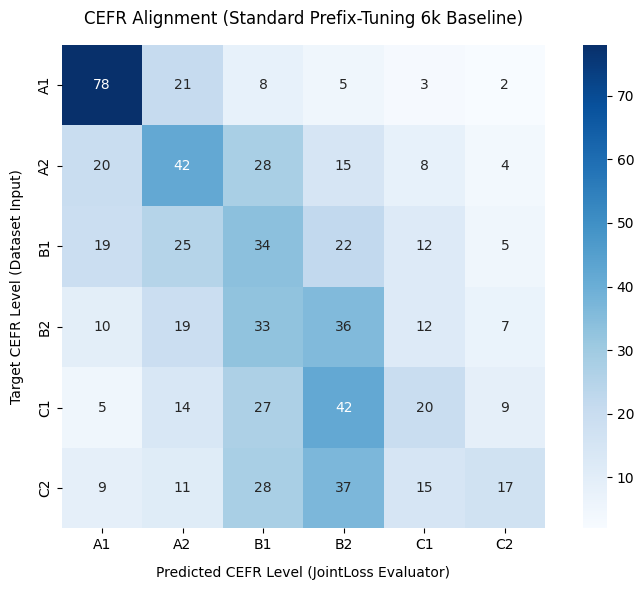

In [ ]:
# ==========================================
# 4. REPORT EXPORT GENERATION
# ==========================================
y_true = df_final['target_cefr']
y_pred = df_final['predicted_cefr']

strict_acc = df_final['strict_match'].mean() * 100
adj_acc = df_final['adjacent_match'].mean() * 100
mae = mean_absolute_error(y_true.map(label_map), y_pred.map(label_map))
avg_mdd = df_final['mdd'].mean()
avg_flesch = df_final['readability_flesch'].mean()
avg_drift = df_final['sentence_drift_max'].mean()

report_text = "="*60 + "\n"
report_text += " 📊 FINAL COMPILED MACRO-STATISTICS (STANDARD PREFIX-TUNING 6k)\n"
report_text += "="*60 + "\n"
report_text += f"Total Processed       : {len(df_final)}\n"
report_text += f"Strict Accuracy       : {strict_acc:.2f}%\n"
report_text += f"Adjacent Accuracy     : {adj_acc:.2f}%\n"
report_text += f"Mean Abs Error (MAE)  : {mae:.4f}\n"
report_text += f"Avg MDD Score         : {avg_mdd:.2f}\n"
report_text += f"Avg Reading Ease      : {avg_flesch:.2f}\n"
report_text += f"Avg Sentence Drift    : {avg_drift:.2f} levels\n"
report_text += "Avg Perplexity        : (Computed externally)\n"
report_text += "="*60 + "\n\n"

report_text += "📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:\n"
level_agg = df_final.groupby("target_cefr").agg(
    strict_accuracy=("strict_match", lambda x: np.mean(x) * 100),
    avg_mdd=("mdd", "mean"),
    avg_flesch=("readability_flesch", "mean"),
    avg_drift=("sentence_drift_max", "mean")
).round(2)
report_text += level_agg.to_string() + "\n\n"

report_text += "="*60 + "\n"
report_text += "📝 DETAILED CLASSIFICATION REPORT:\n"
cefr_labels = ["A1", "A2", "B1", "B2", "C1", "C2"]
report_text += classification_report(y_true, y_pred, labels=cefr_labels, zero_division=0)
report_text += "\n" + "="*60 + "\n"

# Output and write the TXT file locally
with open(OUTPUT_TXT_PATH, "w") as f:
    f.write(report_text)
print(report_text)

# Plot and export the Confusion Matrix file
cm = confusion_matrix(y_true, y_pred, labels=cefr_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cefr_labels, yticklabels=cefr_labels, cbar=True, square=True)
plt.title("CEFR Alignment (Standard Prefix-Tuning 6k Baseline)", fontsize=12, pad=15)
plt.xlabel("Predicted CEFR Level (JointLoss Evaluator)", fontsize=10, labelpad=10)
plt.ylabel("Target CEFR Level (Dataset Input)", fontsize=10, labelpad=10)
plt.tight_layout()
plt.savefig(OUTPUT_IMG_PATH, dpi=300)
print(f"🎨 Confusion Matrix plot successfully saved to: {OUTPUT_IMG_PATH}")